In [41]:
#IMPORT ALL THE REQUIRED LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error

In [50]:
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [51]:
#ADD NOISE TO THE DATASET
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

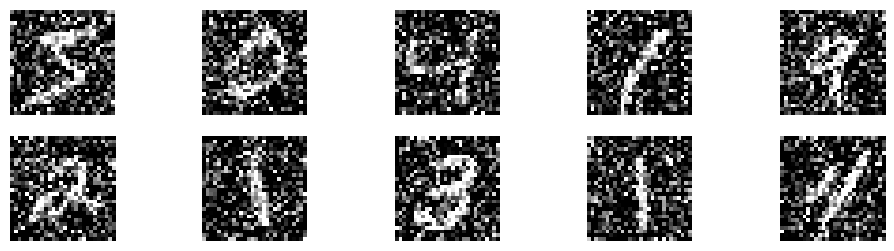

In [52]:
#SHOW NOISY IMAGES
plt.figure(figsize=(12,3))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28),cmap="gray")
    plt.axis("off")

plt.show()

In [53]:
#CNN AUTOENCODER

input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)

x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)

encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder

x = Conv2D(64,(3,3),activation='relu',padding='same')(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img,decoded)

In [54]:
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
#COMPILE THE MODEL
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [56]:
#TRAIN THE MODEL 

history = autoencoder.fit(

    x_train_noisy,
    x_train,

    epochs=20,
    batch_size=128,

    shuffle=True,

    validation_data=(x_test_noisy,x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - loss: 0.1560 - val_loss: 0.1108
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - loss: 0.1081 - val_loss: 0.1045
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - loss: 0.1034 - val_loss: 0.1028
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1010 - val_loss: 0.0992
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0994 - val_loss: 0.0980
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.0982 - val_loss: 0.0970
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.0973 - val_loss: 0.0964
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - loss: 0.0967 - val_loss: 0.0957
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - loss: 0.0961 - val_loss: 0.0952
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0956 - val_loss: 0.0952
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - loss: 0.0952 - val_loss: 0.0948
Epoch 12/20
469/469 ━━━━━━━

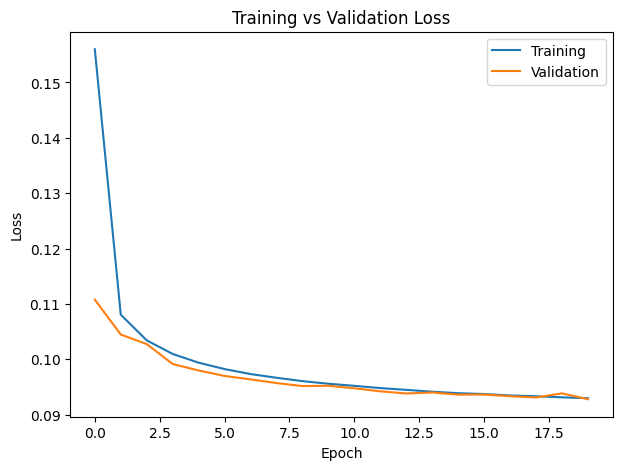

In [57]:
#PLOT LOSS  
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"],label="Training")

plt.plot(history.history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [58]:
#DENOISED IMAGES
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


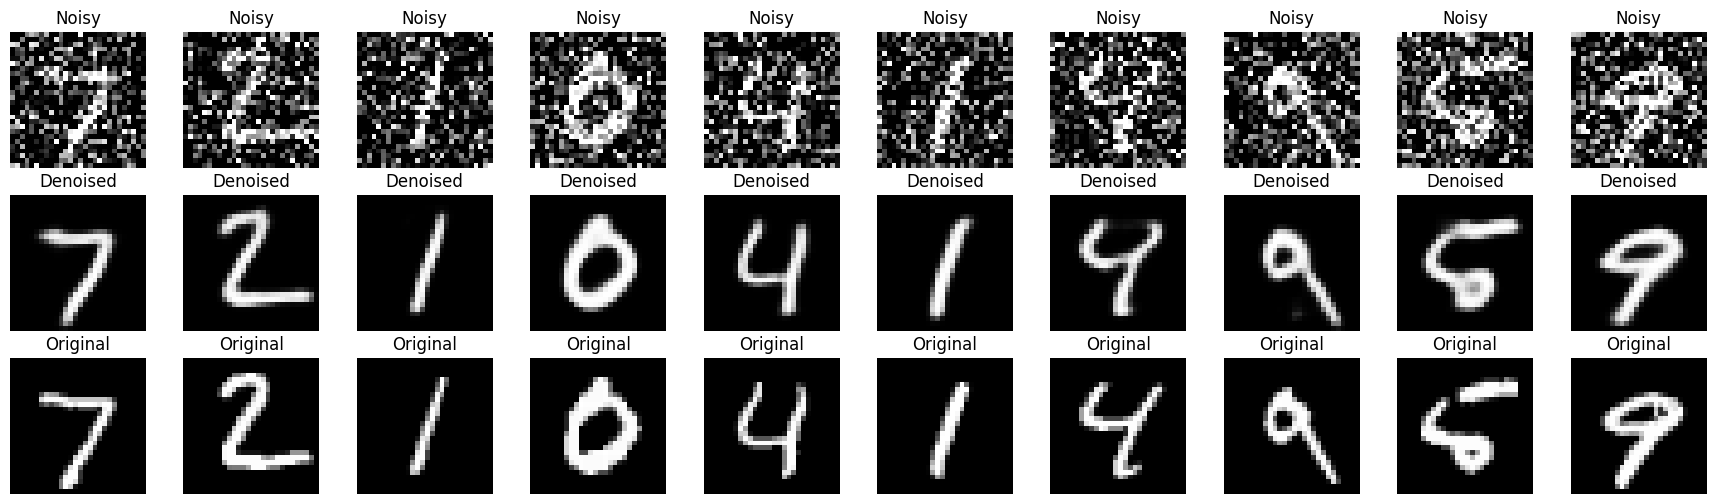

In [59]:
#DISPAY THE RESULTS
n = 10

plt.figure(figsize=(22,6))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    plt.title("Noisy")

    # Denoised Image
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    plt.title("Denoised")

    # Original Image
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    plt.title("Original")

plt.show()

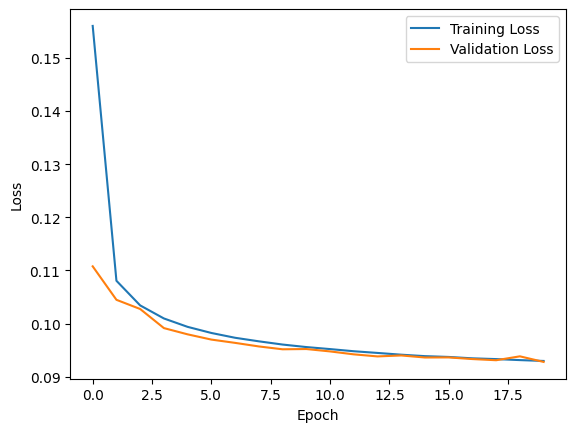

In [60]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#calcuating mean squared error between original and denoised images
mse = mean_squared_error(

    x_test.reshape(-1),

    decoded_imgs.reshape(-1)

)

print("Mean Squared Error :",mse)

Mean Squared Error : 0.010028914548456669


In [63]:
#now save the model
autoencoder.save("image_denoising_autoencoder.keras")

print("Model Saved Successfully")

Model Saved Successfully


## CONCLUSION
 
 THE CONVOLUTIONAL ENCODER SUCCESSFULLY REMOVED GAUSSIAN NOISE FROM THE MNIST HANDWRITTEN DIGIT IMAGES.

 THE DENOISED IMAGE CLEARLY RESEMBLE THE ORIGNAL HANDWRITTEN DIGITS , 

 CNN BASED AUTOENCODERS FOR IMAGE RESTORATION TASKS.